In [60]:
# --- 0) Imports & paths ---
import os, numpy as np, scanpy as sc
from anndata import AnnData
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
import matplotlib.pyplot as plt

# PyTorch imports
import torch
from torch.utils.data import TensorDataset, DataLoader

# Mixed diffusion imports
from mixed_diffusion.train import train
from mixed_diffusion.models.get_model import get_model
from mixed_diffusion.main_utils import get_device
from mixed_diffusion.config_manager import load_model_config
from mixed_diffusion.model_handler import load_existing_model
from mixed_diffusion.preprocessing.data_transformer import DataTransformer

from scipy.spatial.distance import cdist
from tqdm import tqdm
import json

In [61]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:

from sklearn.neighbors import NearestNeighbors, kneighbors_graph
import networkx as nx


def _compute_lisi(X, labels, k=30, metric='cosine'):
    if hasattr(X, "cpu"):
        X = X.cpu().numpy()
    if hasattr(labels, "cpu"):
        labels = labels.cpu().numpy()
    k = min(k, len(X))
    nn = NearestNeighbors(n_neighbors=k, metric=metric).fit(X)
    neigh_idx = nn.kneighbors(return_distance=False)
    lisi_vals = []
    for idxs in neigh_idx:
        local = labels[idxs]
        _, counts = np.unique(local, return_counts=True)
        p = counts / counts.sum()
        simpson = np.sum(p ** 2)
        lisi_vals.append(1.0 / simpson if simpson > 0 else 0.0)
    return np.array(lisi_vals)


def dunn_index(X, labels):
    clusters = [X[labels == i] for i in np.unique(labels)]

    # Intra-cluster diameters
    intra = [cdist(c, c).max() for c in clusters]

    # Inter-cluster distances
    inter = []
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            inter.append(cdist(clusters[i], clusters[j]).min())

    return min(inter) / max(intra)

def modularity_score(X, labels, k=30, metric='cosine'):
    """Compute modularity of label partition on k-NN graph built from X."""
    if hasattr(X, "cpu"):
        X = X.cpu().numpy()
    if hasattr(labels, "cpu"):
        labels = labels.cpu().numpy()
    X = np.asarray(X)
    labels = np.asarray(labels)

    n = X.shape[0]
    if n <= 1:
        return float('nan')

    nn = min(k, max(1, n - 1))
    A = kneighbors_graph(X, n_neighbors=nn, metric=metric, mode='connectivity', include_self=False)
    A = 0.5 * (A + A.T)
    # NetworkX >=3.0 removed from_scipy_sparse_matrix; use from_scipy_sparse_array if available
    try:
        G = nx.from_scipy_sparse_array(A)
    except AttributeError:
        # Fallback: manual construction
        coo = A.tocoo()
        G = nx.Graph()
        G.add_nodes_from(range(A.shape[0]))
        for i, j, v in zip(coo.row, coo.col, coo.data):
            if i != j:
                G.add_edge(i, j, weight=float(v))
    communities = [set(np.where(labels == lab)[0].tolist()) for lab in np.unique(labels)]
    mod = nx.algorithms.community.quality.modularity(G, communities, weight='weight')
    return float(mod)

# Draw the umaps of training - not denoised - denoised

## Plotting code

In [63]:
import os
import matplotlib.pyplot as plt
import umap.umap_ as umap
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.colors as mcolors


def create_shared_color_mapping(results):
    """
    Create a consistent color mapping that matches visualize_umap_python exactly.
    Uses the same labels that visualize_umap_python uses.
    """
    # Use the same labels that visualize_umap_python uses
    labels = results["x_denoised_labels"]
    if hasattr(labels, "cpu"):  # Handle torch tensors
        labels = labels.cpu().numpy()
    
    # Get unique labels and create color mapping - EXACTLY as visualize_umap_python does
    unique_labels = np.unique(labels)
    palette = list(mcolors.TABLEAU_COLORS.values())
    lut = {label: palette[i % len(palette)] for i, label in enumerate(unique_labels)}
    
    return lut, unique_labels


def get_cell_type_name_shared(label_value, label_encoder):
    """Convert numeric label to cell type name using label encoder - same as visualize_umap_python."""
    if label_encoder is None:
        return str(label_value)

    # Check if label_encoder is properly formatted (cell_type -> numeric)
    first_key = next(iter(label_encoder.keys()))
    if isinstance(first_key, (int, float)):
        return str(label_value)

    # label_encoder maps cell_type -> numeric_value, so we need to reverse it
    for cell_type, numeric_value in label_encoder.items():
        if numeric_value == label_value:
            return cell_type
    return str(label_value)


def plot_training_data_umap(results, dataset_name):
    """
    Plot UMAP of training data (y_train) with labels (y_train_labels).
    Uses the EXACT same color scheme as visualize_umap_python for consistency.
    """
    # Check what keys are available in results
    print(f"Available keys in results for {dataset_name}: {list(results.keys())}")
    
    # Try to extract training data - check different possible key names
    y_train = None
    y_train_labels = None
    
    # Check for various possible key names for training data
    possible_train_keys = ['y_train', 'x_train', 'train_data', 'training_data']
    possible_label_keys = ['y_train_labels', 'train_labels', 'y_labels', 'labels']
    
    for key in possible_train_keys:
        if key in results:
            y_train = results[key]
            print(f"Found training data with key: {key}")
            break
    
    for key in possible_label_keys:
        if key in results:
            y_train_labels = results[key]
            print(f"Found training labels with key: {key}")
            break
    
    # If we don't find direct training data, we might need to use test data as proxy
    if y_train is None:
        if 'x_true' in results:
            y_train = results['x_true']
            print("Using 'x_true' as training data proxy")
        elif 'x_denoised' in results:
            y_train = results['x_denoised'] 
            print("Using 'x_denoised' as training data proxy")
    
    if y_train_labels is None:
        if 'x_denoised_labels' in results:
            y_train_labels = results['x_denoised_labels']
            print("Using 'x_denoised_labels' as training labels proxy")
        elif 'true_labels_str' in results:
            # Convert string labels to numeric if needed
            unique_labels = np.unique(results['true_labels_str'])
            label_to_int = {label: i for i, label in enumerate(unique_labels)}
            y_train_labels = np.array([label_to_int[label] for label in results['true_labels_str']])
            print("Using 'true_labels_str' converted to numeric as training labels")
    
    if y_train is None or y_train_labels is None:
        print(f"❌ Could not find suitable training data and labels for {dataset_name}")
        return
    
    # Convert tensors to numpy if needed
    if hasattr(y_train, 'cpu'):
        y_train = y_train.cpu().numpy()
    if hasattr(y_train_labels, 'cpu'):
        y_train_labels = y_train_labels.cpu().numpy()
    
    print(f"Training data shape: {y_train.shape}")
    print(f"Training labels shape: {y_train_labels.shape}")
    print(f"Unique labels: {len(np.unique(y_train_labels))}")
    
    # Create UMAP embedding
    # Apply PCA to reduce dimensionality to 25D before UMAP
    
    # Apply PCA first to reduce to 25 dimensions
    pca = PCA(n_components=15, random_state=42)
    y_train_pca = pca.fit_transform(y_train)
    
    print(f"Data shape after PCA: {y_train_pca.shape}")
    print(f"PCA explained variance ratio sum: {pca.explained_variance_ratio_.sum():.4f}")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42, metric="cosine")
    embedding = reducer.fit_transform(y_train)
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Get the EXACT same color mapping as visualize_umap_python
    lut, reference_unique_labels = create_shared_color_mapping(results)
    
    # Get label encoder for string names if available
    label_encoder = None
    if "data_config" in results and results["data_config"] is not None:
        data_config = results["data_config"]
        if "label_encoder" in data_config:
            label_encoder = data_config["label_encoder"]
    
    # Plot each label separately to create legend entries
    # Use the same unique labels order as visualize_umap_python
    for label in reference_unique_labels:
        mask = y_train_labels == label
        if np.any(mask):
            cell_type_name = get_cell_type_name_shared(label, label_encoder)
            color = lut[label]
            
            ax.scatter(
                embedding[mask, 0],
                embedding[mask, 1],
                s=6,
                alpha=0.8,
                c=color,
                label=cell_type_name,
            )
    
    # Add legend on the right side
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(f"Training Data UMAP: {dataset_name}")
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()


def visualize_umap_python(
    saved_data, args, title="UMAP Visualization", underrepresented_threshold=10.0, save_paths="",
):
    """
    Create UMAP visualization comparing original and denoised data.

    Args:
        saved_data: Dictionary containing data arrays and labels
        args: Arguments object with visualization settings
        title: Plot title
        underrepresented_threshold: Threshold percentage for marking test points as underrepresented.
                                  Test points from cell types with less than this percentage
                                  in the training set will be shown in grey.
        save_paths: output directory where separate PDFs will be written (optional)
    """

    # ensure save directory exists
    if save_paths:
        os.makedirs(save_paths, exist_ok=True)
    save_base = save_paths if save_paths else "."

    # --- 6) Fair UMAP: fit on ORIGINAL TEST, transform DENOISED into same UMAP ---
    um = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0, metric="cosine").fit(
        saved_data["x_true"]
    )
    um2 = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0, metric="cosine").fit(
        saved_data["x_denoised"]
    )
    emb_orig = um.embedding_
    emb_den = um2.embedding_

    # --- 7) Plot side-by-side (same axes space) ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    axes[0].set_title("Original observations")
    axes[1].set_title("Denoised samples")
    import matplotlib.colors as mcolors

    # Handle integer labels properly
    labels = saved_data["x_denoised_labels"]
    if hasattr(labels, "cpu"):  # Handle torch tensors
        labels = labels.cpu().numpy()

    # Get label encoder from data_config if available
    label_encoder = None
    if "data_config" in saved_data and saved_data["data_config"] is not None:
        data_config = saved_data["data_config"]
        if "label_encoder" in data_config:
            label_encoder = data_config["label_encoder"]

    def get_cell_type_name(label_value):
        """Convert numeric label to cell type name using label encoder."""
        if label_encoder is None:
            return str(label_value)

        # Check if label_encoder is properly formatted (cell_type -> numeric)
        first_key = next(iter(label_encoder.keys()))
        if isinstance(first_key, (int, float)):
            return str(label_value)

        # label_encoder maps cell_type -> numeric_value, so we need to reverse it
        for cell_type, numeric_value in label_encoder.items():
            if numeric_value == label_value:
                return cell_type
        return str(label_value)

    # Check if training data is available to calculate representation percentages
    underrepresented_labels = set()

    # Look for training labels in saved_data
    train_labels_key = None
    for key in ["train_labels", "y_train_labels", "true_labels_train"]:
        if key in saved_data:
            train_labels_key = key
            break

    if train_labels_key is not None:
        train_labels = saved_data[train_labels_key]
        if hasattr(train_labels, "cpu"):  # Handle torch tensors
            train_labels = train_labels.cpu().numpy()

        # Calculate label percentages in training set
        unique_train_labels, train_counts = np.unique(train_labels, return_counts=True)
        total_train_samples = len(train_labels)

        print(f"Training set label distribution:")
        for label, count in zip(unique_train_labels, train_counts):
            percentage = (count / total_train_samples) * 100
            cell_type_name = get_cell_type_name(label)
            print(
                f"  {cell_type_name} (label {label}): {count}/{total_train_samples} ({percentage:.1f}%)"
            )

            # Mark labels with < threshold% representation as underrepresented
            if percentage < underrepresented_threshold:
                underrepresented_labels.add(label)
                print(
                    f"    -> Marking as underrepresented (< {underrepresented_threshold}%)"
                )

    else:
        print(
            "Warning: Training labels not found in saved_data. All test points will use normal colors."
        )
        print("Available keys:", list(saved_data.keys()))

    # Get unique labels and create color mapping
    unique_labels = np.unique(labels)
    palette = list(mcolors.TABLEAU_COLORS.values())
    lut = {label: palette[i % len(palette)] for i, label in enumerate(unique_labels)}

    # Plot each label separately to create legend entries (for combined view)
    for label in unique_labels:
        mask = labels == label
        if np.any(mask):
            cell_type_name = get_cell_type_name(label)

            # Use grey for underrepresented labels, normal color otherwise
            if label in underrepresented_labels:
                color = "lightgrey"
                cell_type_name += f" (< {underrepresented_threshold}% in training)"
                alpha = 0.6  # Make underrepresented points slightly more transparent
            else:
                color = lut[label]
                alpha = 0.8

            # Plot on both axes with same color and label
            axes[0].scatter(
                emb_orig[mask, 0],
                emb_orig[mask, 1],
                s=6,
                alpha=alpha,
                c=color,
                label=cell_type_name,
            )
            axes[1].scatter(
                emb_den[mask, 0], emb_den[mask, 1], s=6, alpha=alpha, c=color
            )

    # Add legend only to the first subplot to avoid duplication
    axes[0].legend(bbox_to_anchor=(0, 1), loc="best", fontsize="small")

    for ax in axes:
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.grid(True, alpha=0.2)

    plt.suptitle(title)
    plt.tight_layout()

    # --- Save separate figures for original and denoised ---
    try:
        # Original
        fig_o, ax_o = plt.subplots(1, 1, figsize=(8, 6))
        for label in unique_labels:
            mask = labels == label
            if np.any(mask):
                cell_type_name = get_cell_type_name(label)
                if label in underrepresented_labels:
                    color = "lightgrey"
                    alpha = 0.6
                else:
                    color = lut[label]
                    alpha = 0.8
                ax_o.scatter(emb_orig[mask, 0], emb_orig[mask, 1], s=40, alpha=alpha, c=color, label=cell_type_name)
        # ax_o.set_title(f"{title} - PCA")
        # ax_o.set_xlabel("UMAP 1")
        # ax_o.set_ylabel("UMAP 2")
        ax_o.grid(True, alpha=0.2)
        #ax_o.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
        orig_pdf = os.path.join(save_base, f"{title}_original.pdf")
        fig_o.savefig(orig_pdf, dpi=300)
        plt.close(fig_o)

        # Denoised
        fig_d, ax_d = plt.subplots(1, 1, figsize=(8, 6))
        for label in unique_labels:
            mask = labels == label
            if np.any(mask):
                cell_type_name = get_cell_type_name(label)
                if label in underrepresented_labels:
                    color = "lightgrey"
                    alpha = 0.6
                else:
                    color = lut[label]
                    alpha = 0.8
                ax_d.scatter(emb_den[mask, 0], emb_den[mask, 1], s=40, alpha=alpha, c=color, label=cell_type_name)
        # ax_d.set_title(f"{title} - DICE")
        # ax_d.set_xlabel("UMAP 1")
        # ax_d.set_ylabel("UMAP 2")
        ax_d.grid(True, alpha=0.2)
        #ax_d.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
        den_pdf = os.path.join(save_base, f"{title}_denoised.pdf")
        fig_d.savefig(den_pdf, dpi=300)
        plt.close(fig_d)

        print(f"Saved separate PDFs:\n  {orig_pdf}\n  {den_pdf}")
    except Exception as e:
        print("Could not save separate PDFs:", e)

    scores = {}


    sil_score_original = silhouette_score(saved_data["x_true"], saved_data["x_denoised_labels"], metric='cosine')
    sil_score_denoised = silhouette_score(saved_data["x_denoised"], saved_data["x_denoised_labels"], metric='cosine')

    lisi_original_vals = _compute_lisi(saved_data["x_true"], saved_data["x_denoised_labels"], k=30)
    lisi_denoised_vals = _compute_lisi(saved_data["x_denoised"], saved_data["x_denoised_labels"], k=30)
    lisi_score_original = float(np.mean(lisi_original_vals))
    lisi_score_denoised = float(np.mean(lisi_denoised_vals))

    dunn_score_original = dunn_index(saved_data["x_true"], saved_data["x_denoised_labels"])
    dunn_score_denoised = dunn_index(saved_data["x_denoised"], saved_data["x_denoised_labels"])
    # Modularity (k-NN graph) for original and denoised
    modularity_original = modularity_score(saved_data["x_true"], saved_data["x_denoised_labels"], k=30)
    modularity_denoised = modularity_score(saved_data["x_denoised"], saved_data["x_denoised_labels"], k=30)

    scores['silhouette_original'] = sil_score_original
    scores['silhouette_denoised'] = sil_score_denoised
    scores['lisi_original_mean'] = lisi_score_original
    scores['lisi_denoised_mean'] = lisi_score_denoised
    scores['dunn_original'] = dunn_score_original
    scores['dunn_denoised'] = dunn_score_denoised
    scores['modularity_original'] = modularity_original
    scores['modularity_denoised'] = modularity_denoised

    
    
    print(f"\n=== Silhouette Scores ===")
    print(f"Original data silhouette score: {sil_score_original:.4f}")
    print(f"Denoised data silhouette score: {sil_score_denoised:.4f}")
    print(f"Improvement: {sil_score_denoised - sil_score_original:.4f}")
        
    # Calculate ARI for both original and denoised data
    # ari_results = calculate_clustering_ari(
    #     saved_data["x_true"], saved_data["x_denoised"], labels, emb_orig, emb_den
    # )

    # Print the results
    # print(f"\n=== Clustering Performance (ARI) ===")
    # print(f"Original data ARI: {ari_results['ari_original']:.4f}")
    # print(f"Denoised data ARI: {ari_results['ari_denoised']:.4f}")

    # plt.savefig(f"{args.result_dir}/denoising_comparison_umap.png", dpi=300)

    plt.show()

    return scores


# Plotting


Searching pattern: results/synthetic_d/medium/denoise_train_as_test
  Found: synthetic_d_medium_denoise_train_as_test

Searching pattern: results/synthetic_d/medium/15pca_latent_multivariate_noise/gibbs200*
  Found: synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho5.0-5.0_rep10
  Found: synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho20.0-20.0_rep10
  Found: synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho10.0-5.0_rep10
  Found: synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho10.0-10.0_rep10

Searching pattern: results/synthetic_d/medium/15pca_latent_t_mixture/gib*
  Found: synthetic_d_15pca_latent_t_mixture_gibbs200_rho5.0-5.0_rep10
  Found: synthetic_d_15pca_latent_t_mixture_gibbs200_rho20.0-20.0_rep10
  Found: synthetic_d_15pca_latent_t_mixture_gibbs200_rho10.0-5.0_rep10
  Found: synthetic_d_15pca_latent_t_mixture_gibbs200_rho10.0-10.0_rep10

Searching pattern: results/synthetic_d/medium/15pca_latent/gib*
  Found: synthetic_d_15pca_latent_gibbs200_rho

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Training set label distribution:
  0 (label 0): 790/1600 (49.4%)
  1 (label 1): 810/1600 (50.6%)
Saved separate PDFs:
  figures/synthetic_d_15pca_latent_gibbs200_rho20.0-20.0_rep10_original.pdf
  figures/synthetic_d_15pca_latent_gibbs200_rho20.0-20.0_rep10_denoised.pdf

=== Silhouette Scores ===
Original data silhouette score: 0.2399
Denoised data silhouette score: 0.3620
Improvement: 0.1221


/var/folders/mx/8nbm269n3hv_3jv51d0k5jr40000gp/T/ipykernel_41785/2148215097.py:307: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


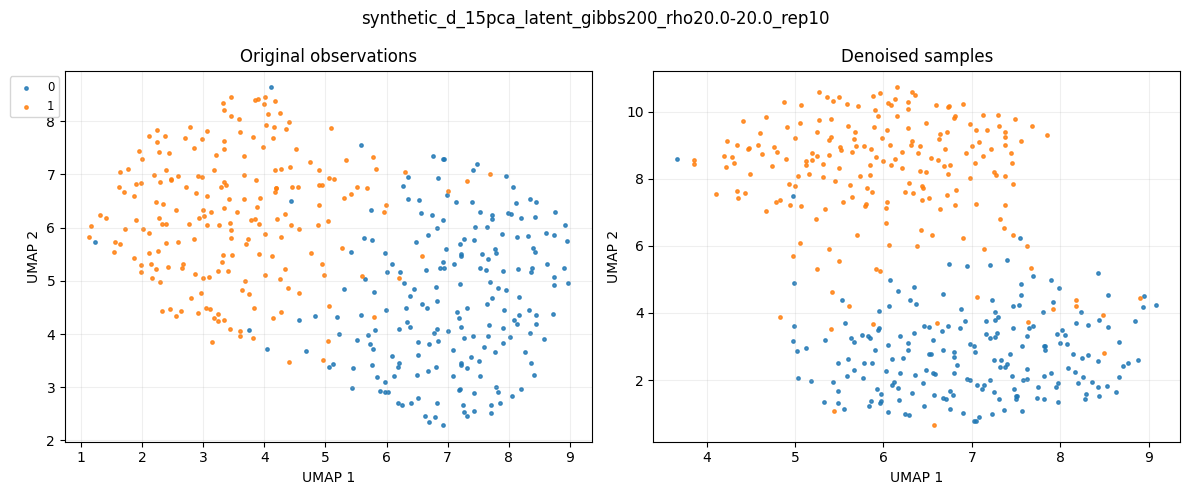

  Loaded args from results/synthetic_d/medium/15pca_latent/gibbs200_rho20.0-20.0_rep10/args.json

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_latent_gibbs200_rho5.0-5.0_rep10

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho10.0-10.0_rep10

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho10.0-5.0_rep10

✓ Loaded results for synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho20.0-20.0_rep10 from results/synthetic_d/medium/15pca_latent_multivariate_noise/gibbs200_rho20.0-20.0_rep10/denoising_results.pt

=== Denoising Comparison for synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho20.0-20.0_rep10 ===
  Mapped to scenario: synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho20.0-20.0_rep10


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Training set label distribution:
  0 (label 0): 790/1600 (49.4%)
  1 (label 1): 810/1600 (50.6%)
Saved separate PDFs:
  figures/synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho20.0-20.0_rep10_original.pdf
  figures/synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho20.0-20.0_rep10_denoised.pdf

=== Silhouette Scores ===
Original data silhouette score: 0.2232
Denoised data silhouette score: 0.3360
Improvement: 0.1127


/var/folders/mx/8nbm269n3hv_3jv51d0k5jr40000gp/T/ipykernel_41785/2148215097.py:307: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


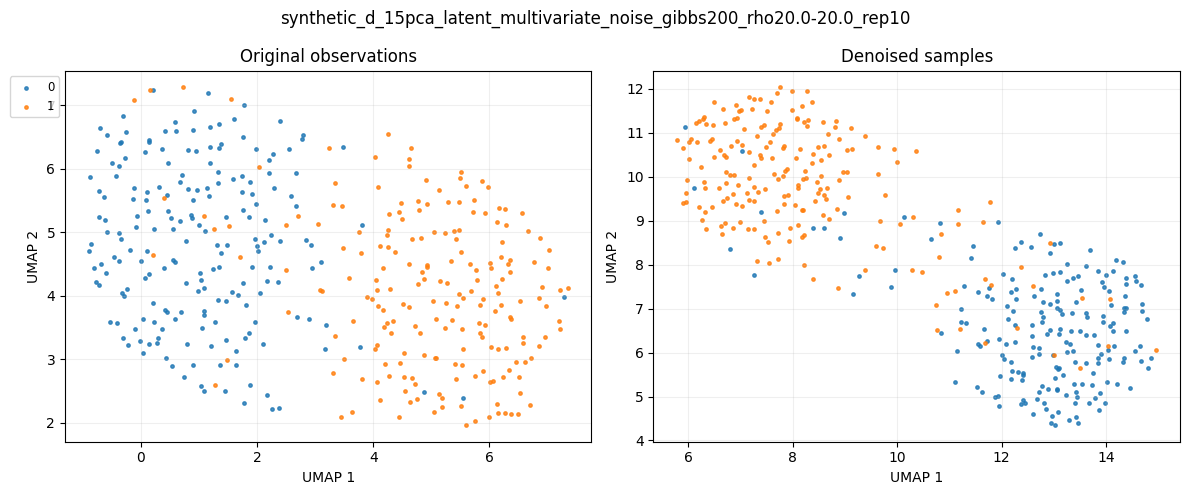

  Loaded args from results/synthetic_d/medium/15pca_latent_multivariate_noise/gibbs200_rho20.0-20.0_rep10/args.json

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho5.0-5.0_rep10

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_latent_t_mixture_gibbs200_rho10.0-10.0_rep10

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_latent_t_mixture_gibbs200_rho10.0-5.0_rep10

✓ Loaded results for synthetic_d_15pca_latent_t_mixture_gibbs200_rho20.0-20.0_rep10 from results/synthetic_d/medium/15pca_latent_t_mixture/gibbs200_rho20.0-20.0_rep10/denoising_results.pt

=== Denoising Comparison for synthetic_d_15pca_latent_t_mixture_gibbs200_rho20.0-20.0_rep10 ===
  Mapped to scenario: synthetic_d_15pca_latent_t_mixture_gibbs200_rho20.0-20.0_rep10


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Training set label distribution:
  0 (label 0): 790/1600 (49.4%)
  1 (label 1): 810/1600 (50.6%)
Saved separate PDFs:
  figures/synthetic_d_15pca_latent_t_mixture_gibbs200_rho20.0-20.0_rep10_original.pdf
  figures/synthetic_d_15pca_latent_t_mixture_gibbs200_rho20.0-20.0_rep10_denoised.pdf

=== Silhouette Scores ===
Original data silhouette score: 0.2187
Denoised data silhouette score: 0.2774
Improvement: 0.0587


/var/folders/mx/8nbm269n3hv_3jv51d0k5jr40000gp/T/ipykernel_41785/2148215097.py:307: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


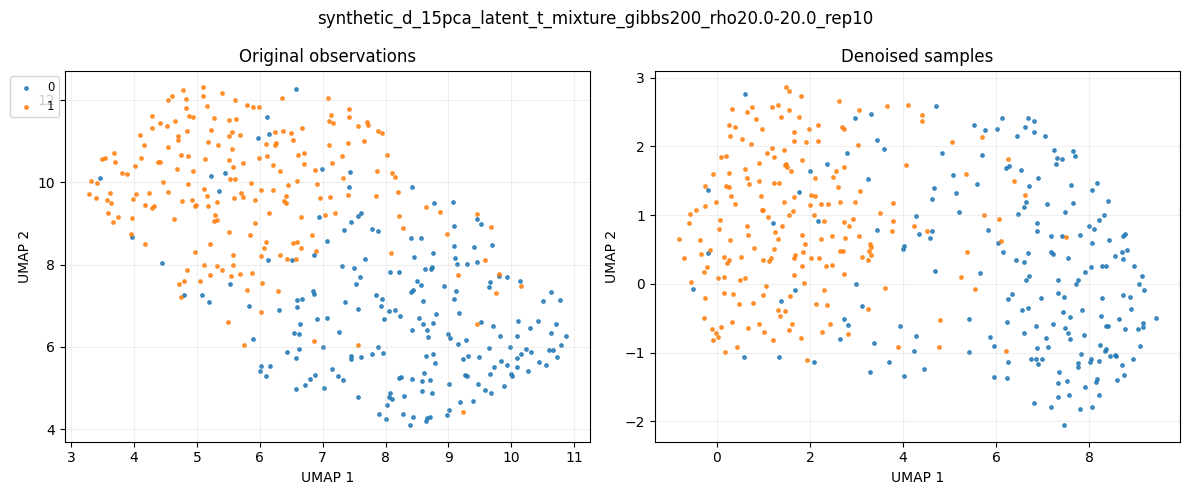

  Loaded args from results/synthetic_d/medium/15pca_latent_t_mixture/gibbs200_rho20.0-20.0_rep10/args.json

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_latent_t_mixture_gibbs200_rho5.0-5.0_rep10

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_quadratic_gibbs200_rho10.0-10.0_rep10

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_quadratic_gibbs200_rho10.0-5.0_rep10

✓ Loaded results for synthetic_d_15pca_quadratic_gibbs200_rho20.0-20.0_rep10 from results/synthetic_d/medium/15pca_quadratic/gibbs200_rho20.0-20.0_rep10/denoising_results.pt

=== Denoising Comparison for synthetic_d_15pca_quadratic_gibbs200_rho20.0-20.0_rep10 ===
  Mapped to scenario: synthetic_d_15pca_quadratic_gibbs200_rho20.0-20.0_rep10

✓ Loaded results for synthetic_d_15pca_quadratic_gibbs200_rho20.0-20.0_rep10 from results/synthetic_d/medium/15pca_quadratic/gibbs200_rho20.0-20.0_rep10/denoising_results.pt

=== Denoising Comparison for synthetic_d_15pca_quadratic_gibbs200_rho20.0-20.0_rep

/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Training set label distribution:
  0 (label 0): 790/1600 (49.4%)
  1 (label 1): 810/1600 (50.6%)
Saved separate PDFs:
  figures/synthetic_d_15pca_quadratic_gibbs200_rho20.0-20.0_rep10_original.pdf
  figures/synthetic_d_15pca_quadratic_gibbs200_rho20.0-20.0_rep10_denoised.pdf

=== Silhouette Scores ===
Original data silhouette score: 0.2187
Denoised data silhouette score: 0.2746
Improvement: 0.0559


/var/folders/mx/8nbm269n3hv_3jv51d0k5jr40000gp/T/ipykernel_41785/2148215097.py:307: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


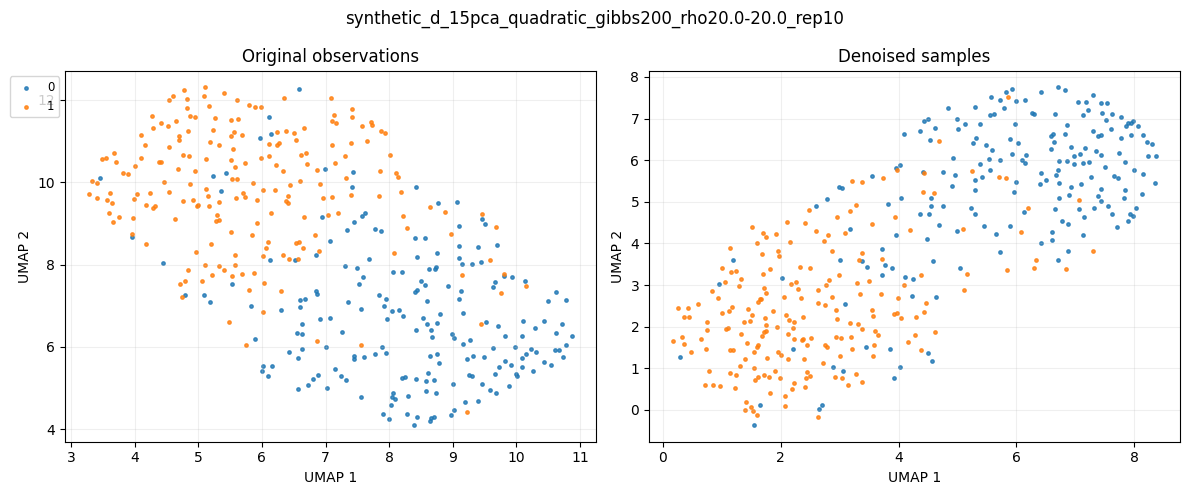

  Loaded args from results/synthetic_d/medium/15pca_quadratic/gibbs200_rho20.0-20.0_rep10/args.json

Skipping dataset (not gibbs200_rho20): synthetic_d_15pca_quadratic_gibbs200_rho5.0-5.0_rep10

✓ Loaded results for synthetic_d_medium_denoise_train_as_test from results/synthetic_d/medium/denoise_train_as_test/denoising_results.pt

=== Denoising Comparison for synthetic_d_medium_denoise_train_as_test ===
  Mapped to scenario: synthetic_d_medium_denoise_train_as_test


/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/mixed_diffusion/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Training set label distribution:
  0 (label 0): 790/1600 (49.4%)
  1 (label 1): 810/1600 (50.6%)
Saved separate PDFs:
  figures/synthetic_d_medium_denoise_train_as_test_original.pdf
  figures/synthetic_d_medium_denoise_train_as_test_denoised.pdf

=== Silhouette Scores ===
Original data silhouette score: 0.2455
Denoised data silhouette score: 0.3704
Improvement: 0.1249


/var/folders/mx/8nbm269n3hv_3jv51d0k5jr40000gp/T/ipykernel_41785/2148215097.py:307: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


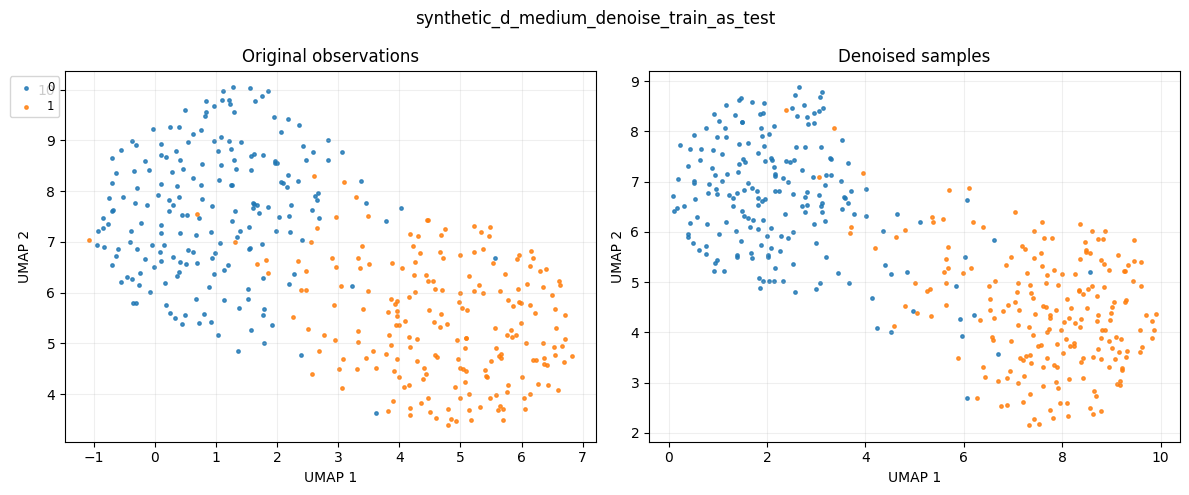

  Loaded args from results/synthetic_d/medium/denoise_train_as_test/args.json


In [64]:
import glob

# Load all datasets that follow multiple patterns
# You can add more patterns to this list as needed
patterns = [
    "results/synthetic_d/medium/denoise_train_as_test",
    "results/synthetic_d/medium/15pca_latent_multivariate_noise/gibbs200*",
    "results/synthetic_d/medium/15pca_latent_t_mixture/gib*",
    "results/synthetic_d/medium/15pca_latent/gib*",
    "results/synthetic_d/medium/15pca_quadratic/gib*"
]

datasets = {}
for pattern in patterns:
    print(f"\nSearching pattern: {pattern}")
    matching_dirs = glob.glob(pattern)
    
    for dir_path in matching_dirs:
        # Extract a meaningful name from the directory path
        dir_name = os.path.basename(dir_path)
        parent_dir = os.path.basename(os.path.dirname(dir_path))
        dataset_key = f"synthetic_d_{parent_dir}_{dir_name}"
        datasets[dataset_key] = dir_path + "/"
        print(f"  Found: {dataset_key}")

print(f"\nTotal found {len(datasets)} datasets across all patterns:")
for name, path in sorted(datasets.items()):
    print(f"  {name}: {path}")

dataset_scores = {}
# Process each dataset
for dataset_name, folder_path in sorted(datasets.items()):
    saved_results_path = os.path.join(folder_path, "denoising_results.pt")

    if "gibbs200_rho20" not in dataset_name and dataset_name != "synthetic_d_medium_denoise_train_as_test":
        print(f"\nSkipping dataset (not gibbs200_rho20): {dataset_name}")
        continue
    if os.path.exists(saved_results_path):
        results = torch.load(saved_results_path, weights_only=False, map_location='cpu')
        print(f"\n✓ Loaded results for {dataset_name} from {saved_results_path}")
        
        # Plot training data UMAP first (only for first dataset to avoid repetition)
        if "VI" not in dataset_name and dataset_name == list(sorted(datasets.keys()))[0]:
            print(f"\n=== Training Data UMAP for {dataset_name} ===")
            plot_training_data_umap(results, dataset_name)
        
        # Then plot the denoising comparison
        print(f"\n=== Denoising Comparison for {dataset_name} ===")
        scenario_name = dataset_name
        print(f"  Mapped to scenario: {scenario_name}")
        scores = visualize_umap_python(results, None, title=scenario_name, underrepresented_threshold=0.1, save_paths="figures")

        # Load args.json file if it exists
        args_path = os.path.join(folder_path, "args.json")
        if os.path.exists(args_path):
            with open(args_path, 'r') as f:
                args_data = json.load(f)
            scores['args'] = args_data
            print(f"  Loaded args from {args_path}")
        else:
            print(f"  Args file not found: {args_path}")
            scores['args'] = None

        dataset_scores[dataset_name] = scores

    else:
        print(f"✗ Results file not found for {dataset_name}: {saved_results_path}")
        continue

In [69]:
import pandas as pd
import json

# Unpack dataset_scores into a flat structure for DataFrame
rows = []
for dataset_name, scores in dataset_scores.items():
    row = {'dataset': dataset_name}
    
    # Add silhouette scores
    row['silhouette_original'] = scores['silhouette_original']
    row['silhouette_denoised'] = scores['silhouette_denoised']
    row['silhouette_improvement'] = scores['silhouette_denoised'] - scores['silhouette_original']

    row['lisi_original_mean'] = scores['lisi_original_mean']
    row['lisi_denoised_mean'] = scores['lisi_denoised_mean']
    row['dunn_original'] = scores['dunn_original']
    row['dunn_denoised'] = scores['dunn_denoised']
    
    # Add args if available
    if scores['args'] is not None:
        # Add key args parameters
        args = scores['args']
        row['rho'] = args.get('rho', None)
        row['rho_start'] = args.get('rho_start', None)
        row['rho_end'] = args.get('rho_end', None)
        row['gibbs_iterations'] = args.get('gibbs_iterations', None)
        row['num_samples'] = args.get('num_samples', None)
        row['repeated_sampling_factor'] = args.get('repeated_sampling_factor', None)
        row['test_noise_level'] = args.get('test_noise_level', None)
        row['noise_level_for_training'] = args.get('noise_level_for_training', None)
    
    rows.append(row)

# Convert to DataFrame
df = pd.DataFrame(rows)

# Sort by silhouette improvement for better visualization
df = df.sort_values('silhouette_improvement', ascending=False)
# Create a mapping function to extract scenarios from dataset names

# Apply the mapping to create the new scenario column
map_dataset_to_scenario = {
    "synthetic_d_medium_denoise_train_as_test": "Scenario 1",
    "synthetic_d_15pca_latent_gibbs200_rho20.0-20.0_rep10": "Scenario 2",
    "synthetic_d_15pca_latent_multivariate_noise_gibbs200_rho20.0-20.0_rep10": "Scenario 3",
    "synthetic_d_15pca_latent_t_mixture_gibbs200_rho20.0-20.0_rep10": "Scenario 4",
}


df['scenario'] = df['dataset'].apply(lambda x: map_dataset_to_scenario.get(x, "Unknown"))

print(f"Dataset scores converted to DataFrame with {len(df)} rows and {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")
print("\nTop 5 datasets by silhouette improvement:")
print(df[['scenario', 'dataset', 'silhouette_original', 'silhouette_denoised', 'lisi_original_mean', 'lisi_denoised_mean', 'dunn_original', 'dunn_denoised']].head())

df

Dataset scores converted to DataFrame with 5 rows and 17 columns
Columns: ['dataset', 'silhouette_original', 'silhouette_denoised', 'silhouette_improvement', 'lisi_original_mean', 'lisi_denoised_mean', 'dunn_original', 'dunn_denoised', 'rho', 'rho_start', 'rho_end', 'gibbs_iterations', 'num_samples', 'repeated_sampling_factor', 'test_noise_level', 'noise_level_for_training', 'scenario']

Top 5 datasets by silhouette improvement:
     scenario                                            dataset  \
4  Scenario 1           synthetic_d_medium_denoise_train_as_test   
0  Scenario 2  synthetic_d_15pca_latent_gibbs200_rho20.0-20.0...   
1  Scenario 3  synthetic_d_15pca_latent_multivariate_noise_gi...   
2  Scenario 4  synthetic_d_15pca_latent_t_mixture_gibbs200_rh...   
3     Unknown  synthetic_d_15pca_quadratic_gibbs200_rho20.0-2...   

   silhouette_original  silhouette_denoised  lisi_original_mean  \
4             0.245550             0.370450            1.266245   
0             0.239933  

,dataset,silhouette_original,silhouette_denoised,silhouette_improvement,lisi_original_mean,lisi_denoised_mean,dunn_original,dunn_denoised,rho,rho_start,rho_end,gibbs_iterations,num_samples,repeated_sampling_factor,test_noise_level,noise_level_for_training,scenario
4,synthetic_d_medium_denoise_train_as_test,0.245550,0.370450,0.124900,1.266245,1.165996,0.196721,0.203716,0.7,20.0,20.0,200,5000,10,0.0,0.0,Scenario 1
0,synthetic_d_15pca_latent_gibbs200_rho20.0-20.0...,0.239933,0.362039,0.122106,1.273076,1.174086,0.239000,0.157811,0.7,20.0,20.0,200,5000,10,0.0,0.0,Scenario 2
1,synthetic_d_15pca_latent_multivariate_noise_gi...,0.223247,0.335979,0.112732,1.315670,1.183160,0.054120,0.052895,0.7,20.0,20.0,200,5000,10,0.0,0.0,Scenario 3
2,synthetic_d_15pca_latent_t_mixture_gibbs200_rh...,0.218674,0.277418,0.058744,1.345331,1.274362,0.133259,0.140968,0.7,20.0,20.0,200,5000,10,0.0,0.0,Scenario 4
3,synthetic_d_15pca_quadratic_gibbs200_rho20.0-2...,0.218674,0.274616,0.055942,1.345331,1.281828,0.133259,0.151664,0.7,20.0,20.0,200,5000,10,0.0,0.0,Unknown


In [72]:
df_20 = df[df['rho_start'] == 20]
df_20 = df_20[["scenario", "silhouette_original", "silhouette_denoised", "lisi_original_mean", "lisi_denoised_mean"]]
df_20 = df_20.sort_values('scenario')
df_20.to_csv("results_synthetic_d_summary.csv", index=False)
latex_str = df_20.to_latex(index=False, float_format="%.2f")
with open("results_synthetic_d_summary.tex", "w") as f:
    f.write(latex_str)
latex_str

'\\begin{tabular}{lrrrr}\n\\toprule\nscenario & silhouette_original & silhouette_denoised & lisi_original_mean & lisi_denoised_mean \\\\\n\\midrule\nScenario 1 & 0.25 & 0.37 & 1.27 & 1.17 \\\\\nScenario 2 & 0.24 & 0.36 & 1.27 & 1.17 \\\\\nScenario 3 & 0.22 & 0.34 & 1.32 & 1.18 \\\\\nScenario 4 & 0.22 & 0.28 & 1.35 & 1.27 \\\\\nUnknown & 0.22 & 0.27 & 1.35 & 1.28 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [67]:

# Display the updated dataframe with scenario counts
print(f"Scenario distribution:")
print(df['scenario'].value_counts())
print(f"\nDataFrame with scenario column:")
df[['dataset', 'scenario', 'silhouette_improvement']].head(10)
df

Scenario distribution:
scenario
Scenario 1    1
Scenario 2    1
Scenario 3    1
Scenario 4    1
Unknown       1
Name: count, dtype: int64

DataFrame with scenario column:


,dataset,silhouette_original,silhouette_denoised,silhouette_improvement,lisi_original_mean,lisi_denoised_mean,dunn_original,dunn_denoised,rho,rho_start,rho_end,gibbs_iterations,num_samples,repeated_sampling_factor,test_noise_level,noise_level_for_training,scenario
4,synthetic_d_medium_denoise_train_as_test,0.245550,0.370450,0.124900,1.266245,1.165996,0.196721,0.203716,0.7,20.0,20.0,200,5000,10,0.0,0.0,Scenario 1
0,synthetic_d_15pca_latent_gibbs200_rho20.0-20.0...,0.239933,0.362039,0.122106,1.273076,1.174086,0.239000,0.157811,0.7,20.0,20.0,200,5000,10,0.0,0.0,Scenario 2
1,synthetic_d_15pca_latent_multivariate_noise_gi...,0.223247,0.335979,0.112732,1.315670,1.183160,0.054120,0.052895,0.7,20.0,20.0,200,5000,10,0.0,0.0,Scenario 3
2,synthetic_d_15pca_latent_t_mixture_gibbs200_rh...,0.218674,0.277418,0.058744,1.345331,1.274362,0.133259,0.140968,0.7,20.0,20.0,200,5000,10,0.0,0.0,Scenario 4
3,synthetic_d_15pca_quadratic_gibbs200_rho20.0-2...,0.218674,0.274616,0.055942,1.345331,1.281828,0.133259,0.151664,0.7,20.0,20.0,200,5000,10,0.0,0.0,Unknown
